# 04 - Distance metrics: Levenshtein, Jaccard, normalised TED

Three edit distances to gold on the same canonical token streams as notebook 03, all normalised to [0, 1] where 0 means identical (lower is better): normalised token-level Levenshtein, Jaccard token-set distance (order and multiplicity insensitive), and the headline normalised Tree Edit Distance (TED). The TED is a shallow clause tree (one child per clause head for Cypher and AQL, one node per step for Gremlin) compared with APTED and divided by the larger tree size, so moving a predicate between clauses costs more than reordering tokens within one. All three primitives live in `harness.distances`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import matplotlib.pyplot as plt
from harness import (
    FIGURES_DIR,
    METRICS_DISTANCE_CSV,
    RECORDS_DIR,
    frames,
    load_records,
    plots,
)
from harness.distances import jaccard, levenshtein, normalized_ted

OUT_CSV = METRICS_DISTANCE_CSV
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Helper methods

In [2]:
METRIC_COLS = ["levenshtein", "jaccard", "normalized_ted"]
FEATURES = frames.feature_map("ldbc")


# Thin wrappers over harness.frames (lower is better for every distance here); the per-model
# cells below stay query_results(target, model) / summary_by_model(target).
def query_results(target, model):
    """Per-query distances for one (target, model) cell (lower is better)."""
    return frames.query_results(dist_df, target, model, METRIC_COLS)


def summary_by_model(target):
    """Mean distances for one target, by model (canonical order, lower is better)."""
    return frames.summary_by_model(dist_df, target, METRIC_COLS)

## Prerequisites

**Identity sanity test**: every gold query against itself must give all three distances 0.0.

In [3]:
# Identity sanity test: every gold query scored against itself must be distance 0 on all three
# metrics, or canonicalisation / a distance has silently drifted.
frames.identity_check([
    ("levenshtein", levenshtein, 0.0),
    ("jaccard", jaccard, 0.0),
    ("normalized_ted", normalized_ted, 0.0),
])

Identity test: 45 cases; failures: 0
PASS


,dataset,query_id,target,levenshtein,jaccard,normalized_ted
0,ldbc,ldbc_q01,cypher,0.0,0.0,0.0
1,ldbc,ldbc_q01,aql,0.0,0.0,0.0
2,ldbc,ldbc_q01,gremlin,0.0,0.0,0.0
3,ldbc,ldbc_q02,cypher,0.0,0.0,0.0
4,ldbc,ldbc_q02,aql,0.0,0.0,0.0
5,ldbc,ldbc_q02,gremlin,0.0,0.0,0.0
6,ldbc,ldbc_q03,cypher,0.0,0.0,0.0
7,ldbc,ldbc_q03,aql,0.0,0.0,0.0
8,ldbc,ldbc_q03,gremlin,0.0,0.0,0.0
9,ldbc,ldbc_q04,cypher,0.0,0.0,0.0


## Compute distances on the records

A missing translation (validation failure) scores the worst distance of 1.0, not dropped.

In [4]:
def _distances(translated, expected, target):
    return {
        "levenshtein": levenshtein(translated, expected, target),
        "jaccard": jaccard(translated, expected, target),
        "normalized_ted": normalized_ted(translated, expected, target),
    }


# A missing translation scores the worst distance (1.0) on every metric. validation_passed is
# carried for the validated-only distance boxplots and dropped again at CSV-save time.
dist_df = frames.compute_metrics_frame(
    load_records(RECORDS_DIR),
    _distances,
    {"levenshtein": 1.0, "jaccard": 1.0, "normalized_ted": 1.0},
    extra=("thinking_used", "validation_passed"),
)
print(f"Computed distances for {len(dist_df)} records.")

Computed distances for 225 records.


## SQL to Cypher

### llama3.2:latest

In [5]:
query_results('cypher', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.489796,0.483871,0.480000
2,ldbc_q03,easy,0.475000,0.375000,0.463415
3,ldbc_q04,hard,0.026316,0.074074,0.026316
4,ldbc_q05,hard,0.571429,0.512195,0.596774
5,ldbc_q06,medium,0.368421,0.310345,0.392857
6,ldbc_q07,medium,0.478261,0.386364,0.473118
7,ldbc_q08,hard,0.652542,0.463415,0.672269
8,ldbc_q09,medium,0.389610,0.250000,0.421053
9,ldbc_q10,hard,0.387755,0.258065,0.395833


### qwen3-coder:30b

In [6]:
query_results('cypher', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.295455,0.037037,0.295455
4,ldbc_q05,hard,0.621622,0.250000,0.625000
5,ldbc_q06,medium,0.170732,0.115385,0.166667
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.119048,0.031250,0.152941
8,ldbc_q09,medium,0.328125,0.205882,0.375000
9,ldbc_q10,hard,0.048780,0.076923,0.050000


### gemma4:26b

In [7]:
query_results('cypher', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.000000,0.000000,0.000000
4,ldbc_q05,hard,0.250000,0.096774,0.250000
5,ldbc_q06,medium,0.000000,0.000000,0.000000
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.000000,0.000000,0.000000
8,ldbc_q09,medium,0.218750,0.000000,0.218750
9,ldbc_q10,hard,0.000000,0.000000,0.000000


### claude-opus-4-8

In [8]:
query_results('cypher', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.026316,0.037037,0.026316
4,ldbc_q05,hard,0.312500,0.096774,0.312500
5,ldbc_q06,medium,0.000000,0.000000,0.000000
6,ldbc_q07,medium,0.200000,0.030303,0.197183
7,ldbc_q08,hard,0.000000,0.000000,0.000000
8,ldbc_q09,medium,0.230769,0.031250,0.230769
9,ldbc_q10,hard,0.088889,0.000000,0.090909


### claude-opus-4-8-thinking

In [9]:
query_results('cypher', 'claude-opus-4-8-thinking')

,query_id,difficulty,levenshtein,jaccard,normalized_ted,thinking_used
0,ldbc_q01,easy,0.000000,0.000000,0.000000,False
1,ldbc_q02,easy,0.000000,0.000000,0.000000,True
2,ldbc_q03,easy,0.291667,0.235294,0.360000,False
3,ldbc_q04,hard,0.026316,0.037037,0.026316,False
4,ldbc_q05,hard,0.312500,0.096774,0.312500,True
5,ldbc_q06,medium,0.000000,0.000000,0.000000,False
6,ldbc_q07,medium,0.200000,0.030303,0.197183,False
7,ldbc_q08,hard,0.107143,0.031250,0.105882,True
8,ldbc_q09,medium,0.000000,0.000000,0.000000,True
9,ldbc_q10,hard,0.000000,0.000000,0.000000,False


### Aggregation by model

In [10]:
summary_by_model('cypher')

,levenshtein,jaccard,normalized_ted
model,,,
llama3.2:latest,0.395912,0.282476,0.404789
qwen3-coder:30b,0.202439,0.091002,0.210969
gemma4:26b,0.050895,0.011370,0.050576
claude-opus-4-8,0.066417,0.018580,0.066173
claude-opus-4-8-thinking,0.077879,0.036488,0.081915


### Figures

In [11]:
sub = dist_df[dist_df["target"] == 'cypher']
label = 'SQL -> Cypher'
prefix = 'cypher'

#### Normalised TED by query x model (lower is better)

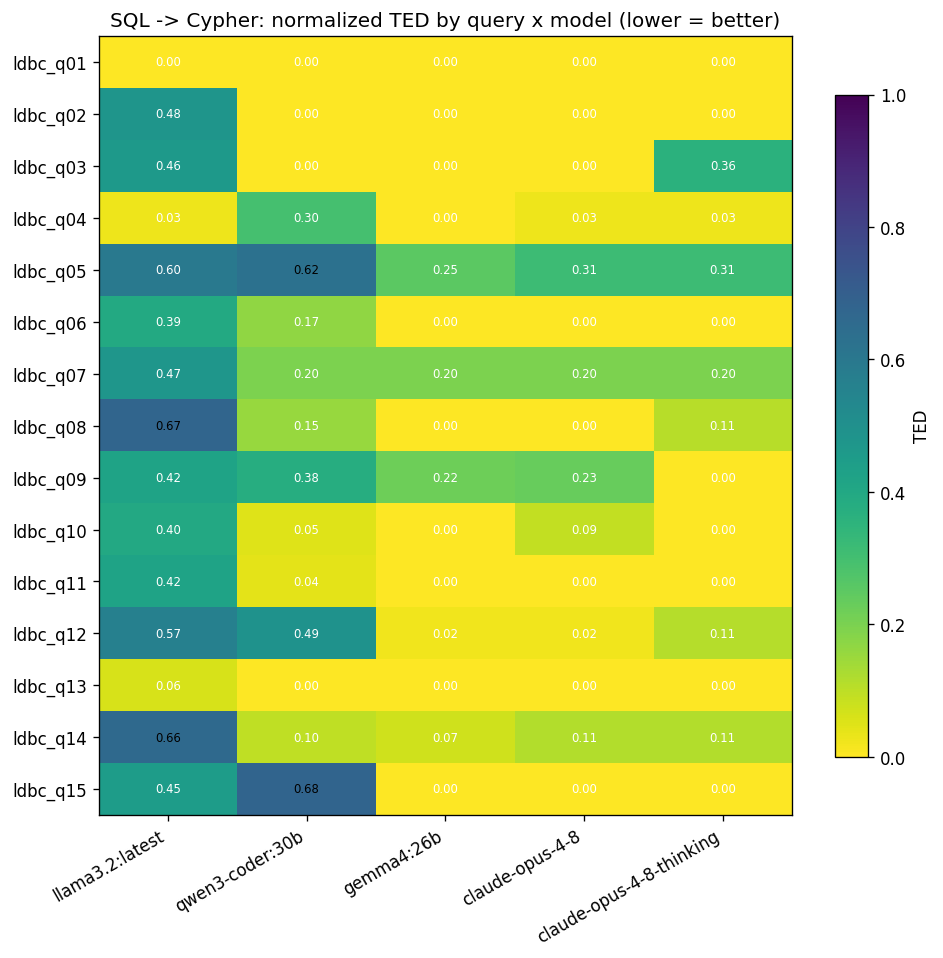

In [12]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Edit distance distribution per model (validated only, lower is better)

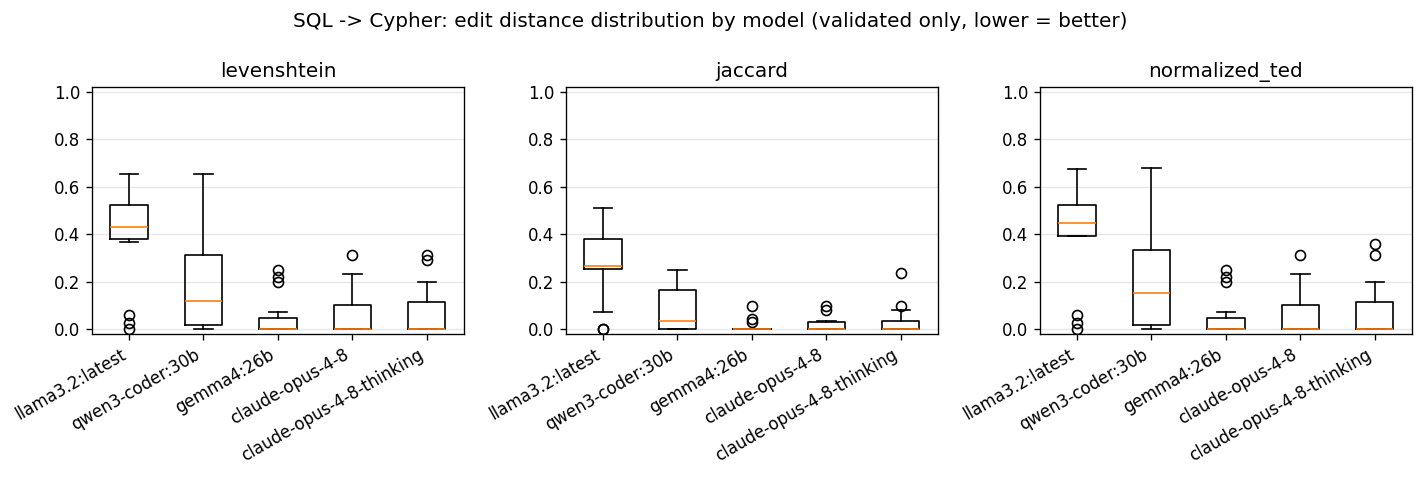

In [13]:
p = FIGURES_DIR / f"{prefix}_distance_by_model.png"
plots.distance_boxplots(sub, p, title=f"{label}: edit distance distribution by model (validated only, lower = better)")
plots.show(p)
plt.close("all")

## SQL to AQL

### llama3.2:latest

In [14]:
query_results('aql', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.023810,0.105263,0.023256
1,ldbc_q02,easy,0.078947,0.181818,0.076923
2,ldbc_q03,easy,0.066667,0.222222,0.064516
3,ldbc_q04,hard,0.380000,0.281250,0.392157
4,ldbc_q05,hard,0.507463,0.410256,0.544118
5,ldbc_q06,medium,0.407407,0.406250,0.436364
6,ldbc_q07,medium,0.333333,0.314286,0.342466
7,ldbc_q08,hard,0.690789,0.549020,0.738562
8,ldbc_q09,medium,0.513514,0.428571,0.533333
9,ldbc_q10,hard,0.367347,0.363636,0.380000


### qwen3-coder:30b

In [15]:
query_results('aql', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.071429,0.142857,0.069767
1,ldbc_q02,easy,0.027778,0.050000,0.027027
2,ldbc_q03,easy,0.100000,0.210526,0.096774
3,ldbc_q04,hard,0.622951,0.285714,0.645161
4,ldbc_q05,hard,0.507246,0.342105,0.542857
5,ldbc_q06,medium,0.166667,0.192308,0.163265
6,ldbc_q07,medium,0.220588,0.156250,0.246377
7,ldbc_q08,hard,0.290323,0.181818,0.287234
8,ldbc_q09,medium,0.445946,0.378378,0.453333
9,ldbc_q10,hard,0.295455,0.080000,0.288889


### gemma4:26b

In [16]:
query_results('aql', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.000000,0.000000,0.000000
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.000000,0.000000,0.000000
3,ldbc_q04,hard,0.622222,0.393939,0.652174
4,ldbc_q05,hard,0.322034,0.243243,0.316667
5,ldbc_q06,medium,0.125000,0.120000,0.122449
6,ldbc_q07,medium,0.117647,0.035714,0.115942
7,ldbc_q08,hard,0.333333,0.222222,0.361702
8,ldbc_q09,medium,0.405405,0.305556,0.400000
9,ldbc_q10,hard,0.355556,0.080000,0.347826


### claude-opus-4-8

In [17]:
query_results('aql', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.071429,0.142857,0.069767
1,ldbc_q02,easy,0.000000,0.000000,0.000000
2,ldbc_q03,easy,0.033333,0.117647,0.032258
3,ldbc_q04,hard,0.282609,0.074074,0.276596
4,ldbc_q05,hard,0.481013,0.270270,0.500000
5,ldbc_q06,medium,0.125000,0.120000,0.122449
6,ldbc_q07,medium,0.147059,0.100000,0.144928
7,ldbc_q08,hard,0.193548,0.100000,0.191489
8,ldbc_q09,medium,0.405405,0.305556,0.400000
9,ldbc_q10,hard,0.295455,0.080000,0.288889


### claude-opus-4-8-thinking

In [18]:
query_results('aql', 'claude-opus-4-8-thinking')

,query_id,difficulty,levenshtein,jaccard,normalized_ted,thinking_used
0,ldbc_q01,easy,0.071429,0.142857,0.069767,True
1,ldbc_q02,easy,0.027778,0.050000,0.027027,True
2,ldbc_q03,easy,0.066667,0.111111,0.064516,True
3,ldbc_q04,hard,0.282609,0.074074,0.276596,True
4,ldbc_q05,hard,0.101695,0.121212,0.100000,True
5,ldbc_q06,medium,0.125000,0.120000,0.122449,True
6,ldbc_q07,medium,0.147059,0.100000,0.144928,True
7,ldbc_q08,hard,0.193548,0.100000,0.191489,True
8,ldbc_q09,medium,0.243243,0.228571,0.240000,True
9,ldbc_q10,hard,0.295455,0.080000,0.288889,True


### Aggregation by model

In [19]:
summary_by_model('aql')

,levenshtein,jaccard,normalized_ted
model,,,
llama3.2:latest,0.398245,0.380687,0.414359
qwen3-coder:30b,0.321504,0.210901,0.325791
gemma4:26b,0.221080,0.135399,0.226171
claude-opus-4-8,0.225533,0.136637,0.224506
claude-opus-4-8-thinking,0.190906,0.124516,0.191370


### Figures

In [20]:
sub = dist_df[dist_df["target"] == 'aql']
label = 'SQL -> AQL'
prefix = 'aql'

#### Normalised TED by query x model (lower is better)

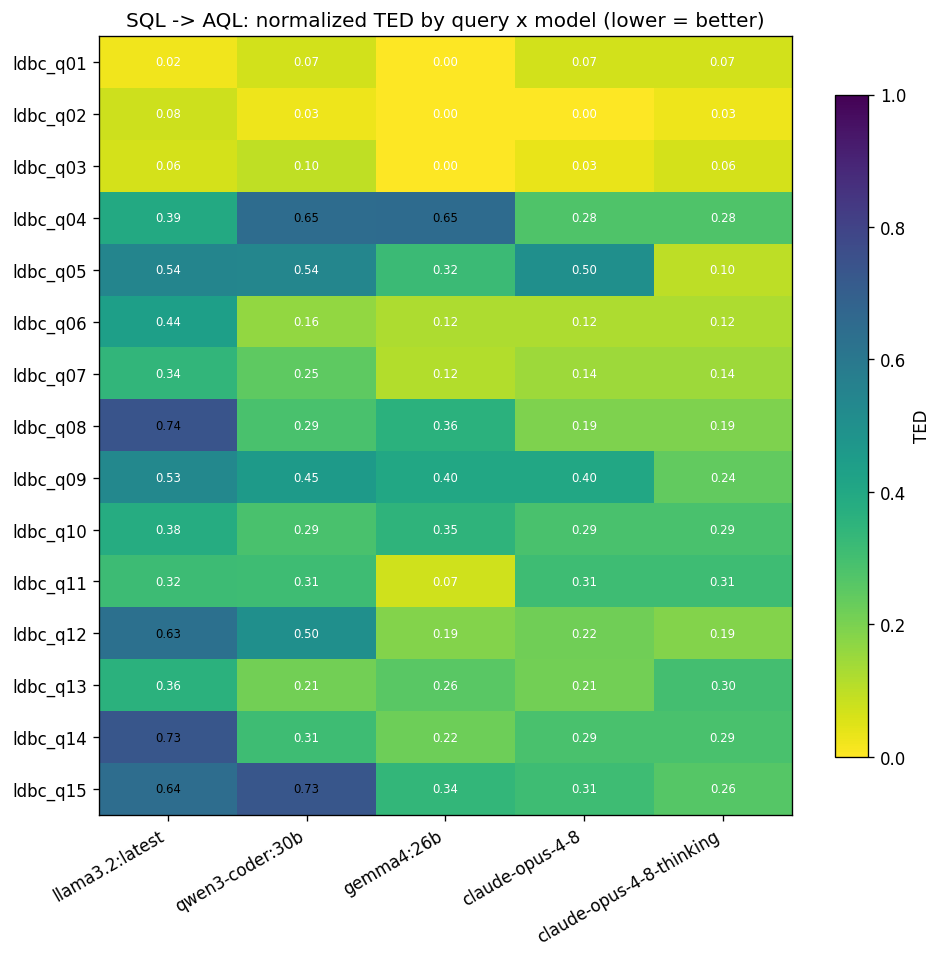

In [21]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Edit distance distribution per model (validated only, lower is better)

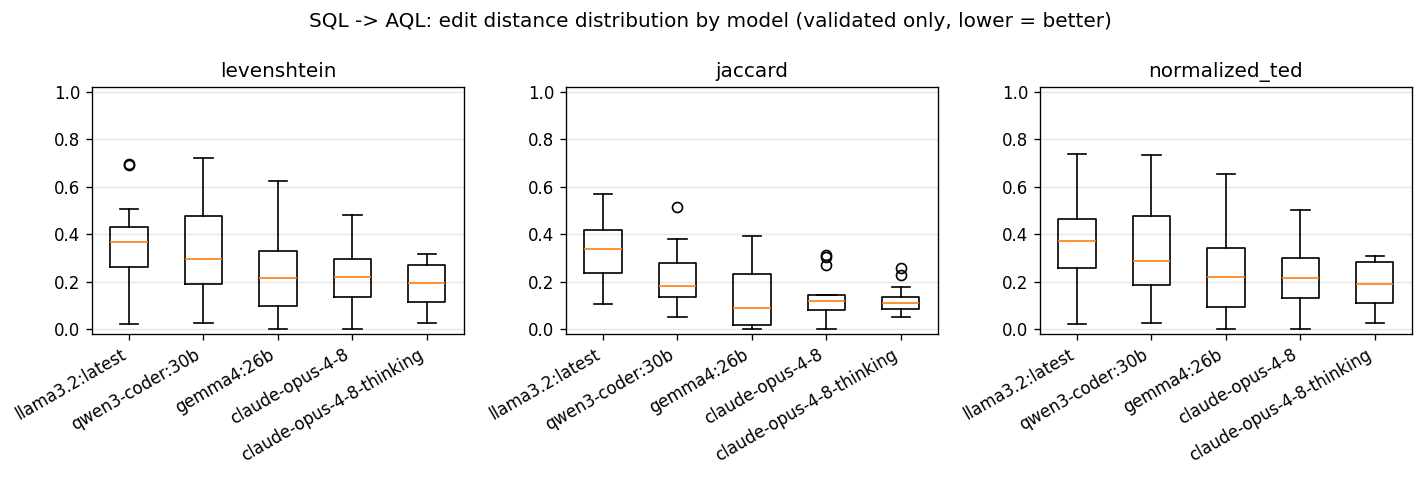

In [22]:
p = FIGURES_DIR / f"{prefix}_distance_by_model.png"
plots.distance_boxplots(sub, p, title=f"{label}: edit distance distribution by model (validated only, lower = better)")
plots.show(p)
plt.close("all")

## SQL to Gremlin

### llama3.2:latest

In [23]:
query_results('gremlin', 'llama3.2:latest')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.423077,0.277778,0.391304
1,ldbc_q02,easy,0.573333,0.555556,0.970588
2,ldbc_q03,easy,0.447368,0.200000,0.470588
3,ldbc_q04,hard,0.535714,0.500000,0.800000
4,ldbc_q05,hard,0.655172,0.574468,0.836066
5,ldbc_q06,medium,0.675325,0.481481,0.870968
6,ldbc_q07,medium,0.682927,0.660000,0.897059
7,ldbc_q08,hard,0.448052,0.441176,0.619048
8,ldbc_q09,medium,0.635593,0.457143,0.693878
9,ldbc_q10,hard,0.541176,0.413793,0.594595


### qwen3-coder:30b

In [24]:
query_results('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.057692,0.157895,0.130435
1,ldbc_q02,easy,0.226667,0.208333,0.218750
2,ldbc_q03,easy,0.170732,0.176471,0.277778
3,ldbc_q04,hard,0.554745,0.241379,0.703704
4,ldbc_q05,hard,0.603175,0.342857,0.800000
5,ldbc_q06,medium,0.441558,0.423077,0.612903
6,ldbc_q07,medium,0.518293,0.228571,0.544118
7,ldbc_q08,hard,0.873150,0.630769,0.942257
8,ldbc_q09,medium,0.500000,0.228571,0.734694
9,ldbc_q10,hard,0.559322,0.200000,0.617021


### gemma4:26b

In [25]:
query_results('gremlin', 'gemma4:26b')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.145455,0.200000,0.250000
1,ldbc_q02,easy,0.226667,0.208333,0.218750
2,ldbc_q03,easy,0.121951,0.066667,0.166667
3,ldbc_q04,hard,0.081081,0.125000,0.100000
4,ldbc_q05,hard,0.369048,0.111111,0.382353
5,ldbc_q06,medium,0.345794,0.250000,0.454545
6,ldbc_q07,medium,0.091463,0.157895,0.117647
7,ldbc_q08,hard,0.097403,0.088235,0.126984
8,ldbc_q09,medium,0.304965,0.200000,0.465517
9,ldbc_q10,hard,0.084746,0.050000,0.083333


### claude-opus-4-8

In [26]:
query_results('gremlin', 'claude-opus-4-8')

,query_id,difficulty,levenshtein,jaccard,normalized_ted
0,ldbc_q01,easy,0.057692,0.157895,0.130435
1,ldbc_q02,easy,0.240000,0.240000,0.250000
2,ldbc_q03,easy,0.170732,0.176471,0.277778
3,ldbc_q04,hard,0.135135,0.043478,0.133333
4,ldbc_q05,hard,0.098592,0.083333,0.103448
5,ldbc_q06,medium,0.415584,0.320000,0.612903
6,ldbc_q07,medium,0.085366,0.135135,0.102941
7,ldbc_q08,hard,0.344156,0.093750,0.412698
8,ldbc_q09,medium,0.516949,0.200000,0.938776
9,ldbc_q10,hard,0.000000,0.000000,0.000000


### claude-opus-4-8-thinking

In [27]:
query_results('gremlin', 'claude-opus-4-8-thinking')

,query_id,difficulty,levenshtein,jaccard,normalized_ted,thinking_used
0,ldbc_q01,easy,0.057692,0.157895,0.130435,False
1,ldbc_q02,easy,0.240000,0.240000,0.250000,True
2,ldbc_q03,easy,0.170732,0.176471,0.277778,False
3,ldbc_q04,hard,0.472973,0.086957,0.466667,True
4,ldbc_q05,hard,0.454545,0.080000,0.675000,True
5,ldbc_q06,medium,0.428571,0.192308,0.580645,True
6,ldbc_q07,medium,0.085366,0.135135,0.102941,True
7,ldbc_q08,hard,0.051948,0.058824,0.079365,True
8,ldbc_q09,medium,0.346405,0.171429,0.507937,True
9,ldbc_q10,hard,0.000000,0.000000,0.000000,True


### Aggregation by model

In [28]:
summary_by_model('gremlin')

,levenshtein,jaccard,normalized_ted
model,,,
llama3.2:latest,0.572105,0.494409,0.757825
qwen3-coder:30b,0.490007,0.352235,0.608045
gemma4:26b,0.186551,0.161961,0.237387
claude-opus-4-8,0.244464,0.185498,0.347667
claude-opus-4-8-thinking,0.243435,0.170281,0.337021


### Figures

In [29]:
sub = dist_df[dist_df["target"] == 'gremlin']
label = 'SQL -> Gremlin'
prefix = 'gremlin'

#### Normalised TED by query x model (lower is better)

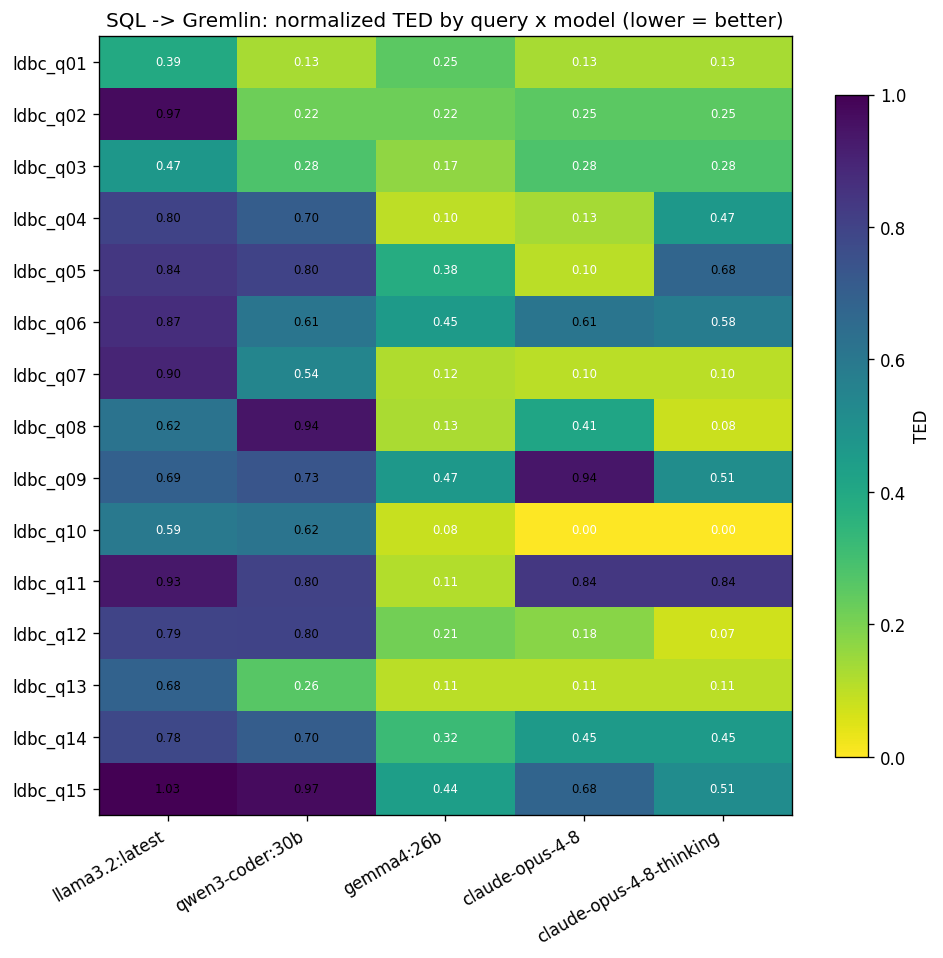

In [30]:
p = FIGURES_DIR / f"{prefix}_query_model_ted.png"
plots.query_model_heatmap(sub, "normalized_ted", p, cmap_name="viridis_r", title=f"{label}: normalized TED by query x model (lower = better)", cbar_label="TED")
plots.show(p)
plt.close("all")

#### Edit distance distribution per model (validated only, lower is better)

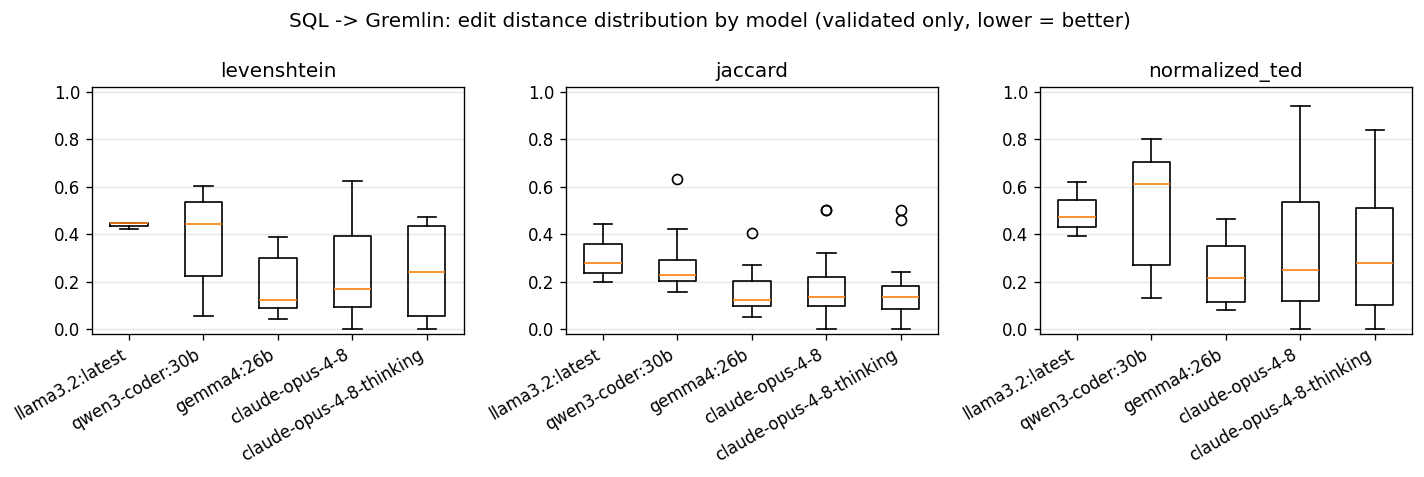

In [31]:
p = FIGURES_DIR / f"{prefix}_distance_by_model.png"
plots.distance_boxplots(sub, p, title=f"{label}: edit distance distribution by model (validated only, lower = better)")
plots.show(p)
plt.close("all")

## Run-level summary (lower is better)

In [32]:
by_model, by_diff, by_feat = frames.run_summary(dist_df, METRIC_COLS, METRIC_COLS, FEATURES)
print("By target x model:")
display(by_model)
print("By target x difficulty:")
display(by_diff)
print("By target x SQL feature:")
display(by_feat)

By target x model:


levenshtein   jaccard  normalized_ted
target  model                                                          
aql     llama3.2:latest              0.398245  0.380687        0.414359
        qwen3-coder:30b              0.321504  0.210901        0.325791
        gemma4:26b                   0.221080  0.135399        0.226171
        claude-opus-4-8              0.225533  0.136637        0.224506
        claude-opus-4-8-thinking     0.190906  0.124516        0.191370
cypher  llama3.2:latest              0.395912  0.282476        0.404789
        qwen3-coder:30b              0.202439  0.091002        0.210969
        gemma4:26b                   0.050895  0.011370        0.050576
        claude-opus-4-8              0.066417  0.018580        0.066173
        claude-opus-4-8-thinking     0.077879  0.036488        0.081915
gremlin llama3.2:latest              0.572105  0.494409        0.757825
        qwen3-coder:30b              0.490007  0.352235        0.608045
        gemma4:26b                   0.186551  0.161961        0.237387
        claude-opus-4-8              0.244464  0.185498        0.347667
        claude-opus-4-8-thinking     0.243435  0.170281        0.337021

By target x difficulty:


levenshtein   jaccard  normalized_ted
target  difficulty                                       
aql     easy           0.042618  0.098477        0.041440
        medium         0.287978  0.212367        0.291636
        hard           0.349005  0.227440        0.356966
cypher  easy           0.083764  0.072944        0.086894
        medium         0.201216  0.105021        0.205999
        hard           0.165559  0.085104        0.169823
gremlin easy           0.221986  0.213318        0.294086
        medium         0.406537  0.342692        0.547702
        hard           0.364698  0.260304        0.473846

By target x SQL feature:


levenshtein   jaccard  normalized_ted
target  feature                                           
aql     aggregation     0.355786  0.189808        0.360246
        cte             0.444324  0.410221        0.457655
        distinct        0.339260  0.236705        0.348822
        join            0.335221  0.226814        0.341290
        order_limit     0.376617  0.250234        0.382555
        subquery        0.320206  0.225723        0.334407
        temporal        0.110019  0.098807        0.112562
        union           0.388808  0.310146        0.400644
cypher  aggregation     0.178713  0.100392        0.180850
        cte             0.216293  0.101590        0.224823
        distinct        0.205211  0.106639        0.214179
        join            0.192474  0.100083        0.197347
        order_limit     0.189230  0.094164        0.194596
        subquery        0.212866  0.105252        0.215560
        temporal        0.176806  0.099145        0.174185
        union           0.288193  0.140063        0.295439
gremlin aggregation     0.371261  0.268535        0.501631
        cte             0.597828  0.555374        0.725604
        distinct        0.351522  0.253740        0.424076
        join            0.397456  0.295789        0.520855
        order_limit     0.417267  0.271143        0.559767
        subquery        0.303912  0.218938        0.405774
        temporal        0.297008  0.276896        0.367279
        union           0.458012  0.346219        0.565686

## Save per-record CSV

In [33]:
print(f"Wrote {frames.save_metrics_csv(dist_df, OUT_CSV, drop=('validation_passed',))} rows to {OUT_CSV}")

Wrote 225 rows to /Users/ivona.obonova/school/sql2graph/sql2graph/eval/outputs/metrics/metrics_distance.csv


## Summary

The three distances agree with Component F1 from the other side and give the same model ranking on every target. Distances grow from Cypher through AQL to Gremlin, where the TED is computed over the method-chain tree and every extra or reordered step counts.

Wrote `metrics_distance.csv`. Proceed to **`05_execution_metrics.ipynb`**.